# Order cell states with pseudotime

A single-cell experiment measures cells at one time point, but it may capture several
stages of a process. **Pseudotime** places those cells along a graph-based coordinate.
In CyteArc, chosen starting and terminal populations orient that coordinate. It does not
measure elapsed time or establish which cells give rise to others.

We use a developing-pancreas dataset to order cells from Ductal-like progenitors toward
Alpha, Beta, and Delta populations, then find genes associated with that ordering.

## Open the prepared analysis

In [1]:
# Work with numeric arrays and cell masks.
import numpy as np

# Summarize cells and results in tables.
import pandas as pd

# Open count stores and run CyteArc analyses.
import cytearc

# Keep routine logs and progress bars out of the results.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the count store for this analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Open the saved pancreas analysis.
analysis_run = ds.pipeline.open(label="docs_default")

# Keep the graph from the saved analysis.
graph = analysis_run["connectivity_map"]

# Keep the full feature selection for marker testing.
all_features = analysis_run["feature_universe"]

# Inspect the opened store's cells and features.
ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'G2M_score', 'RNA_UMAP1', 
            'RNA_UMAP2', 'RNA_clusters', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
            'RNA_percentMito', 'RNA_percentRibo', 'S_score', 'clusters', 'clusters_coarse'
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'highly_variable_genes', 
            'nCells'

Started: 2026-10-08T11:03:30.138108Z | Wall time: 21.079 s

The saved analysis supplies the graph, UMAP, and feature selection. The store's live
`clusters` column contains the published cell-type annotations; these differ from the
numbered clusters calculated by the pipeline.

## Choose a start and endpoints

We use the published Ductal annotation as the source and pool Alpha, Beta, and Delta
as sinks. This is a biological assumption to check with marker evidence, not something
pseudotime discovers for us.

The vector below assigns a total of -1 to the source and +1 to the pooled sinks.
All other cells receive zero. Sharing each total across its cells keeps source and sink
mass balanced despite their different sizes.

In [2]:
# Read the published cell types for the selected cells.
labels = ds.cells.fetch("clusters", key="I")

# Choose Ductal cells as the starting population.
source = labels == "Ductal"

# Choose the pooled endocrine endpoints.
sink = np.isin(labels, ["Alpha", "Beta", "Delta"])

# Stop if either chosen endpoint population is absent.
if not source.any() or not sink.any():
    raise ValueError("Source and sink labels must both be present")

# Start with zero weight for cells outside the endpoints.
source_sink_vector = np.zeros(len(labels), dtype=float)

# Share a total weight of minus one across the source cells.
source_sink_vector[source] = -1.0 / source.sum()

# Share a total weight of plus one across the sink cells.
source_sink_vector[sink] = 1.0 / sink.sum()

# Check the endpoint sizes and balanced total weights.
{
    "source cells": int(source.sum()),
    "sink cells": int(sink.sum()),
    "source weight": round(float(source_sink_vector[source].sum()), 6),
    "sink weight": round(float(source_sink_vector[sink].sum()), 6),
}

{'source cells': 916,
 'sink cells': 1142,
 'source weight': -1.0,
 'sink weight': 1.0}

Started: 2026-10-08T11:03:51.221769Z | Wall time: 0.028 s

## Score and view pseudotime

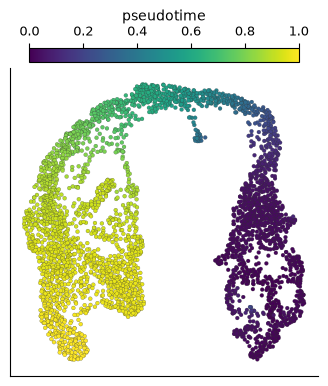

Started: 2026-10-08T11:03:51.252548Z | Wall time: 2.835 s

In [3]:
# Score pseudotime using the chosen source and sink weights.
pseudotime_ref = ds.trajectory.pseudotime(graph, ss_vec=source_sink_vector)

# Load pseudotime scores and their validity mask.
pseudotime = ds.trajectory.load_pseudotime(pseudotime_ref)

# Save the calculated values in the cell table.
ds.cells.insert("pseudotime", pseudotime.values, key="I", overwrite=True)

# Show how pseudotime changes across the pancreas UMAP.
ds.plots.embedding(layout=analysis_run['umap'], color_by='pseudotime', sort_values=True)

Low values should lie toward the Ductal region and high values toward the endocrine
endpoints. The default rescales the score from zero to one. Intermediate values are
expected for intermediate populations; the spacing is not a clock.

Check the score within each annotation, using only cells marked valid:

In [4]:
# Summarize the selected values and their spread.
pd.DataFrame(
    {
        "cell type": labels[pseudotime.valid],
        "pseudotime": pseudotime.values[pseudotime.valid],
    }
).groupby("cell type")["pseudotime"].describe()

,count,mean,std,min,25%,50%,75%,max
cell type,,,,,,,,
Alpha,481.0,0.959114,0.011427,0.856333,0.955074,0.962445,0.966974,0.975449
Beta,591.0,0.969954,0.019940,0.911869,0.955499,0.969878,0.987021,1.000000
Delta,70.0,0.920987,0.006449,0.902592,0.918507,0.922015,0.923473,0.944463
Ductal,916.0,0.022884,0.015787,0.000000,0.010547,0.024064,0.030442,0.120687
Epsilon,142.0,0.923247,0.028827,0.836076,0.909276,0.928915,0.946695,0.960882
Ngn3 high EP,642.0,0.500495,0.176410,0.086914,0.377537,0.549324,0.625577,0.770497
Ngn3 low EP,262.0,0.053654,0.037650,0.000237,0.029426,0.039494,0.076645,0.294520
Pre-endocrine,592.0,0.863303,0.061251,0.416378,0.816136,0.876490,0.916908,0.952879


Started: 2026-10-08T11:03:54.090811Z | Wall time: 0.040 s

In this example, Ductal cells have low scores, endocrine endpoints have high scores,
and Ngn3-high progenitors occupy the middle. A pattern that disagrees with known markers
is a reason to revisit the graph or endpoint choice.

## Find genes associated with the ordering

The full result includes untested features, which have missing p-values. The first few rows
may therefore contain `NaN`. Multiple-testing correction covers only the tested features;
we select those after previewing the table.

In [5]:
# Test the selected genes for association with pseudotime.
marker_ref = ds.trajectory.markers(pseudotime_ref, features=all_features)

# Load the marker table and adjusted p-values.
markers = ds.trajectory.load_markers(marker_ref)

# Inspect the first few rows of the result.
markers.table.head()

,feature_index,feature_name,feature_id,r_value,p_value,p_value_adjusted
0,0,Xkr4,Xkr4,0.0,NaN,NaN
1,1,Gm37381,Gm37381,0.0,NaN,NaN
2,2,Rp1,Rp1,0.0,NaN,NaN
3,3,Rp1-1,Rp1-1,0.0,NaN,NaN
4,4,Sox17,Sox17,0.0,NaN,NaN


Started: 2026-10-08T11:03:54.133272Z | Wall time: 4.604 s

Keep tested genes, then compare the strongest increasing and decreasing associations:

In [6]:
# Keep genes with an adjusted p-value.
tested = markers.table.loc[
    markers.table["p_value_adjusted"].notna(),
    ["feature_name", "r_value", "p_value_adjusted"],
]

# Select the ten strongest positive correlations.
increasing = tested.loc[tested["r_value"] > 0].nlargest(10, "r_value")

# Select the ten strongest negative correlations.
decreasing = tested.loc[tested["r_value"] < 0].nsmallest(10, "r_value")

# Display increasing and decreasing genes together.
pd.concat({"increasing": increasing, "decreasing": decreasing})

feature_name   r_value  p_value_adjusted
increasing 14296         Gnas  0.733378               0.0
           23549          Cpe  0.727340               0.0
           21244        Aplp1  0.724762               0.0
           3186       Fam183b  0.667180               0.0
           25060        Hmgn3  0.634982               0.0
           26573         Bex2  0.622286               0.0
           26730       Pcsk1n  0.619715               0.0
           2189         Rap1b  0.598531               0.0
           4284           Ubb  0.596782               0.0
           5837          Scgn  0.593644               0.0
decreasing 18864         Spp1 -0.828283               0.0
           24581        Rpl13 -0.822300               0.0
           22385        Rps19 -0.812887               0.0
           16254         Rps8 -0.809283               0.0
           431            Dbi -0.798267               0.0
           19815        Rpl32 -0.783062               0.0
           26498        Rps4x -0.781889               0.0
           13425        Rpl12 -0.768139               0.0
           10164         Rps2 -0.754498               0.0
           20787        Mgst1 -0.745716               0.0

Started: 2026-10-08T11:03:58.741046Z | Wall time: 0.030 s

Positive correlations identify genes whose expression tends to increase along the
chosen axis; negative correlations identify decreasing genes. These are candidates to
inspect, not evidence that they drive development.

## Common mistakes and limitations
- Treating the ordering as discovered rather than supervised: source and sink choices define the axis, so test plausible alternative endpoints before making a developmental claim.
- Forgetting that only the largest connected graph component is scored by default: excluded cells have `valid=False` and undefined values. Apply the validity mask to your own summaries; CyteArc's pseudotime marker and aggregation methods apply it automatically.
- Relying on correlation alone: genes that rise and fall along the path can be missed, so use [](expression_dynamics.ipynb) to inspect such profiles.


Continue to [](fate_mapping.ipynb) for several possible terminal outcomes, or [](trajectory_validation.md) for checks across graph and endpoint choices.